# 06 - Validación end-to-end

## 1. Dependencias

In [1]:
#Instalar dependencias
%pip install pandas numpy scikit-learn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


## 2. Configuración

In [2]:
#Cargar librerías
import platform
import sys
import unicodedata
from pathlib import Path
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display

In [3]:
#Mostrar versiones
SEMILLA = 20260721

versiones = pd.DataFrame([
    {'componente': 'Python', 'version': platform.python_version()},
    {'componente': 'pandas', 'version': pd.__version__},
    {'componente': 'numpy', 'version': np.__version__},
    {'componente': 'scikit-learn', 'version': sklearn.__version__},
    {'componente': 'matplotlib', 'version': matplotlib.__version__},
    {'componente': 'joblib', 'version': joblib.__version__},
])

display(versiones)

,componente,version
0,Python,3.14.3
1,pandas,3.0.3
2,numpy,2.5.1
3,scikit-learn,1.9.0
4,matplotlib,3.11.1
5,joblib,1.5.3


## 3. Rutas y artefactos

In [4]:
#Definir rutas
ruta_datasets = Path('../Datasets')
ruta_modelos = Path('../Modelos')
ruta_resultados = Path('../Resultados')
ruta_graficas = ruta_resultados / 'Graficas'

archivos = {
    'perfiles': ruta_datasets / 'perfil_integral_usuario.csv',
    'transacciones': ruta_datasets / 'transacciones_contextualizadas.csv',
    'trayectorias': ruta_datasets / 'trayectorias_financieras.csv',
    'decisiones': ruta_datasets / 'decisiones_recomendaciones.csv',
    'modelo_usuario': ruta_modelos / '01_conocimiento_usuario.joblib',
    'modelo_transacciones': ruta_modelos / '02_clasificacion_transacciones.joblib',
    'modelo_estados': ruta_modelos / '04_estados_trayectoria.joblib',
    'modelo_recomendaciones': ruta_modelos / '05_motor_recomendaciones.joblib',
    'recurrencias': ruta_resultados / '03_recurrencias_observadas.csv',
    'tendencias': ruta_resultados / '03_tendencias_observadas.csv',
    'eventos': ruta_resultados / '03_eventos_inusuales.csv',
    'estados': ruta_resultados / '04_estados_trayectoria.csv',
    'metricas_estados': ruta_resultados / '04_metricas_modelo.csv',
    'recomendaciones': ruta_resultados / '05_recomendaciones.csv',
    'metricas_recomendaciones': ruta_resultados / '05_metricas_modelo.csv',
}

ruta_graficas.mkdir(parents=True, exist_ok=True)

In [5]:
#Revisar archivos
inventario = pd.DataFrame([
    {
        'artefacto': nombre,
        'ruta': str(ruta),
        'existe': ruta.exists(),
        'tamano_kb': round(ruta.stat().st_size / 1024, 2) if ruta.exists() else np.nan,
    }
    for nombre, ruta in archivos.items()
])

display(inventario)
assert inventario['existe'].all(), 'Faltan artefactos necesarios para ejecutar el recorrido completo'

,artefacto,ruta,existe,tamano_kb
0,perfiles,../Datasets/perfil_integral_usuario.csv,True,195.68
1,transacciones,../Datasets/transacciones_contextualizadas.csv,True,7458.79
2,trayectorias,../Datasets/trayectorias_financieras.csv,True,531.13
3,decisiones,../Datasets/decisiones_recomendaciones.csv,True,667.33
4,modelo_usuario,../Modelos/01_conocimiento_usuario.joblib,True,643.92
5,modelo_transacciones,../Modelos/02_clasificacion_transacciones.joblib,True,4500.33
6,modelo_estados,../Modelos/04_estados_trayectoria.joblib,True,4499.84
7,modelo_recomendaciones,../Modelos/05_motor_recomendaciones.joblib,True,1400.30
8,recurrencias,../Resultados/03_recurrencias_observadas.csv,True,1306.62
9,tendencias,../Resultados/03_tendencias_observadas.csv,True,30.20


## 4. Carga sin entrenamiento

In [6]:
#Cargar productos
perfiles = pd.read_csv(archivos['perfiles'])
transacciones = pd.read_csv(archivos['transacciones'])
trayectorias = pd.read_csv(archivos['trayectorias'])
decisiones = pd.read_csv(archivos['decisiones'])
recurrencias = pd.read_csv(archivos['recurrencias'])
tendencias = pd.read_csv(archivos['tendencias'])
eventos = pd.read_csv(archivos['eventos'])
estados = pd.read_csv(archivos['estados'])
metricas_estados = pd.read_csv(archivos['metricas_estados'])
recomendaciones = pd.read_csv(archivos['recomendaciones'])
metricas_recomendaciones = pd.read_csv(archivos['metricas_recomendaciones'])

artefacto_usuario = joblib.load(archivos['modelo_usuario'])
artefacto_transacciones = joblib.load(archivos['modelo_transacciones'])
artefacto_estados = joblib.load(archivos['modelo_estados'])
artefacto_recomendaciones = joblib.load(archivos['modelo_recomendaciones'])

transacciones['fecha'] = pd.to_datetime(transacciones['fecha'], errors='coerce')
transacciones['valor'] = pd.to_numeric(transacciones['valor'], errors='coerce')

In [ ]:
#Resumir carga
resumen_carga = pd.DataFrame([
    {'etapa': '01 conocimiento del usuario', 'producto': type(artefacto_usuario['modelo_actividad']).__name__, 'filas': len(perfiles)},
    {'etapa': '02 clasificación de transacciones', 'producto': type(artefacto_transacciones['modelo_categoria']).__name__, 'filas': len(transacciones)},
    {'etapa': '03 patrones temporales', 'producto': 'resultados auditables', 'filas': len(recurrencias) + len(tendencias) + len(eventos)},
    {'etapa': '04 estados de trayectoria', 'producto': type(artefacto_estados['modelo']).__name__, 'filas': len(estados)},
    {'etapa': '05 recomendaciones', 'producto': type(artefacto_recomendaciones['modelo']).__name__, 'filas': len(recomendaciones)},
])

display(resumen_carga)

## 5. Contratos entre etapas

In [7]:
#Validar claves
claves_requeridas = {
    'usuario': ['modelo_actividad', 'modelos_contexto', 'modelo_hobbies', 'umbral_alcance'],
    'transacciones': ['modelo_categoria', 'modelo_finalidad', 'modelo_confirmacion', 'escala_valor'],
    'estados': ['modelo', 'variables_modelo', 'umbral_confianza', 'clases'],
    'recomendaciones': ['modelo', 'variables_modelo', 'catalogo_recomendaciones', 'guardas_eticas'],
}

artefactos_modelo = {
    'usuario': artefacto_usuario,
    'transacciones': artefacto_transacciones,
    'estados': artefacto_estados,
    'recomendaciones': artefacto_recomendaciones,
}

revision_claves = pd.DataFrame([
    {
        'artefacto': nombre,
        'claves_faltantes': ' | '.join(sorted(set(claves_requeridas[nombre]) - set(artefacto))),
    }
    for nombre, artefacto in artefactos_modelo.items()
])

display(revision_claves)
assert revision_claves['claves_faltantes'].eq('').all(), 'Un modelo no cumple su contrato serializado'

,artefacto,claves_faltantes
0,usuario,
1,transacciones,
2,estados,
3,recomendaciones,


In [8]:
#Construir trazabilidad
conteo_transacciones = transacciones.groupby('perfil_id').size().rename('transacciones_disponibles')
conteo_regularidades = recurrencias.loc[
    recurrencias['estado_patron'].eq('regularidad_observada')
].groupby('perfil_id').size().rename('regularidades_observadas')
conteo_eventos = eventos.groupby('perfil_id').size().rename('eventos_inusuales_observados')

base_perfiles = perfiles[[
    'perfil_id',
    'descripcion_visible',
    'actividad_1_familia',
    'estado_alcance_mvp',
    'particion',
    'es_sintetico',
]].rename(columns={
    'particion': 'particion_perfil',
    'estado_alcance_mvp': 'alcance_perfil',
})

base_estados = estados[[
    'perfil_id',
    'ventana_id',
    'periodo_desde',
    'periodo_hasta',
    'estado_modelo',
    'estado_calculo_modelo',
    'confianza_pct',
    'particion',
]].rename(columns={'particion': 'particion_estado'})

base_recomendaciones = recomendaciones[[
    'perfil_id',
    'ventana_id',
    'periodo_desde',
    'periodo_hasta',
    'estado_trayectoria',
    'estado_motor',
    'recomendacion_id',
    'decision',
    'fuente_seleccion',
    'revision_humana',
    'guardas_aplicadas',
]].rename(columns={
    'ventana_id': 'ventana_recomendacion',
    'periodo_desde': 'periodo_desde_recomendacion',
    'periodo_hasta': 'periodo_hasta_recomendacion',
})

trazabilidad = base_perfiles.merge(base_estados, on='perfil_id', how='left', validate='one_to_one')
trazabilidad = trazabilidad.merge(base_recomendaciones, on='perfil_id', how='left', validate='one_to_one')
trazabilidad = trazabilidad.join(conteo_transacciones, on='perfil_id')
trazabilidad = trazabilidad.join(conteo_regularidades, on='perfil_id')
trazabilidad = trazabilidad.join(conteo_eventos, on='perfil_id')
trazabilidad[['regularidades_observadas', 'eventos_inusuales_observados']] = trazabilidad[[
    'regularidades_observadas',
    'eventos_inusuales_observados',
]].fillna(0).astype(int)

In [9]:
#Comprobar integración
trazabilidad['estado_coherente'] = trazabilidad['estado_modelo'].eq(trazabilidad['estado_trayectoria'])
trazabilidad['ventana_coherente'] = trazabilidad['ventana_id'].eq(trazabilidad['ventana_recomendacion'])
trazabilidad['periodo_coherente'] = (
    trazabilidad['periodo_desde'].eq(trazabilidad['periodo_desde_recomendacion'])
    & trazabilidad['periodo_hasta'].eq(trazabilidad['periodo_hasta_recomendacion'])
)

trazabilidad['particion_coherente'] = trazabilidad['particion_perfil'].eq(trazabilidad['particion_estado'])
trazabilidad['recorrido_completo'] = (
    trazabilidad['estado_motor'].eq('recomendacion_disponible')
    & trazabilidad['transacciones_disponibles'].gt(0)
    & trazabilidad['estado_coherente']
    & trazabilidad['ventana_coherente']
    & trazabilidad['periodo_coherente']
    & trazabilidad['particion_coherente']
)

controles_integracion = pd.DataFrame([
    {'control': 'identificadores de perfil únicos', 'errores': int(perfiles['perfil_id'].duplicated().sum())},
    {'control': 'un estado actual por perfil', 'errores': int(estados['perfil_id'].duplicated().sum())},
    {'control': 'una recomendación actual por perfil', 'errores': int(recomendaciones['perfil_id'].duplicated().sum())},
    {'control': 'perfiles sin transacciones', 'errores': int(trazabilidad['transacciones_disponibles'].isna().sum())},
    {'control': 'estado inconsistente', 'errores': int((~trazabilidad['estado_coherente']).sum())},
    {'control': 'ventana inconsistente', 'errores': int((~trazabilidad['ventana_coherente']).sum())},
    {'control': 'periodo inconsistente', 'errores': int((~trazabilidad['periodo_coherente']).sum())},
    {'control': 'partición inconsistente', 'errores': int((~trazabilidad['particion_coherente']).sum())},
])

display(controles_integracion)
assert controles_integracion['errores'].eq(0).all(), 'El recorrido end-to-end contiene contratos inconsistentes'

,control,errores
0,identificadores de perfil únicos,0
1,un estado actual por perfil,0
2,una recomendación actual por perfil,0
3,perfiles sin transacciones,0
4,estado inconsistente,0
5,ventana inconsistente,0
6,periodo inconsistente,0
7,partición inconsistente,0


## 6. Controles éticos y de alcance

In [10]:
#Auditar guardas
mascara_critica = recomendaciones['estado_trayectoria'].eq('situacion_critica')
mascara_fragilidad = recomendaciones['estado_trayectoria'].eq('fragilidad_sostenida')
mascara_hobbies = recomendaciones['hobbies_considerados'].fillna('no_declarado').ne('no_declarado')

guarda_hobbies = recomendaciones['guardas_aplicadas'].fillna('').apply(
    lambda valor: 'hobbies_no_eliminados_automaticamente' in str(valor)
)

controles_eticos = pd.DataFrame([
    {
        'control': 'situación crítica con contención',
        'errores': int(recomendaciones.loc[mascara_critica, 'recomendacion_id'].ne('REC_PLAN_CONTENCION').sum()),
    },
    {
        'control': 'situación crítica con revisión humana',
        'errores': int(recomendaciones.loc[mascara_critica, 'revision_humana'].ne('requerida').sum()),
    },
    {
        'control': 'fragilidad con cobertura protegida',
        'errores': int(recomendaciones.loc[mascara_fragilidad, 'recomendacion_id'].ne('REC_PRIORIZAR_COBERTURA').sum()),
    },
    {
        'control': 'hobbies declarados conservados',
        'errores': int((mascara_hobbies & ~guarda_hobbies).sum()),
    },
    {
        'control': 'fuente de selección declarada',
        'errores': int(recomendaciones['fuente_seleccion'].isna().sum()),
    },
])

display(controles_eticos)
assert controles_eticos['errores'].eq(0).all(), 'Una guarda ética dejó de cumplirse'

,control,errores
0,situación crítica con contención,0
1,situación crítica con revisión humana,0
2,fragilidad con cobertura protegida,0
3,hobbies declarados conservados,0
4,fuente de selección declarada,0


## 7. Inferencia integrada

In [11]:
#Normalizar entradas
def normalizar_texto(texto):
    texto_normalizado = unicodedata.normalize('NFKD', str(texto))
    texto_sin_tildes = ''.join(
        caracter
        for caracter in texto_normalizado
        if not unicodedata.combining(caracter)
    )
    return ' '.join(texto_sin_tildes.lower().strip().split())

def valor_texto(valor, reemplazo='no_declarado'):
    if pd.isna(valor) or not str(valor).strip():
        return reemplazo
    return str(valor).strip()

def cortar_al_final(texto, finales):
    segmento = texto
    for final in finales:
        if final in segmento:
            segmento = segmento.split(final, 1)[0]
    return segmento.strip(' .,:;')

In [12]:
#Separar contexto
def extraer_actividad_principal(texto):
    texto_normalizado = normalizar_texto(texto)
    return cortar_al_final(
        texto_normalizado,
        ['.', ' tambien ', ' en mi tiempo libre ', ' quiero ', ' tengo como responsabilidad '],
    )

def extraer_actividad_secundaria(texto):
    texto_normalizado = normalizar_texto(texto)
    marcadores = [
        'tambien genero ingresos con ',
        'tambien trabajo como ',
        'ademas genero ingresos con ',
    ]
    for marcador in marcadores:
        if marcador in texto_normalizado:
            segmento = texto_normalizado.split(marcador, 1)[1]
            return cortar_al_final(
                segmento,
                ['.', ' en mi tiempo libre ', ' quiero ', ' tengo como responsabilidad '],
            )
    return ''

def extraer_hobbies(texto):
    texto_normalizado = normalizar_texto(texto)
    marcadores = [
        'en mi tiempo libre disfruto ',
        'en mi tiempo libre me gusta ',
        'mis hobbies son ',
    ]
    for marcador in marcadores:
        if marcador in texto_normalizado:
            segmento = texto_normalizado.split(marcador, 1)[1]
            return cortar_al_final(segmento, ['.', ' quiero ', ' tengo como responsabilidad '])
    return ''

In [13]:
#Conocer usuario
def prediccion_simple(modelo, texto):
    probabilidades = modelo.predict_proba([texto])[0]
    posicion = int(np.argmax(probabilidades))
    return str(modelo.classes_[posicion]), float(probabilidades[posicion])

def conocer_usuario(descripcion_usuario):
    if not isinstance(descripcion_usuario, str) or not descripcion_usuario.strip():
        raise ValueError('descripcion_usuario debe contener texto')

    texto_principal = extraer_actividad_principal(descripcion_usuario)
    modelo_actividad = artefacto_usuario['modelo_actividad']
    probabilidades = modelo_actividad.predict_proba([texto_principal])[0]
    orden = np.argsort(probabilidades)[::-1]
    actividad = str(modelo_actividad.classes_[orden[0]])
    confianza = float(probabilidades[orden[0]])
    top_3 = [
        {
            'actividad': str(modelo_actividad.classes_[posicion]),
            'porcentaje': round(float(probabilidades[posicion]) * 100, 2),
        }
        for posicion in orden[:3]
    ]

    if confianza < artefacto_usuario['umbral_alcance']:
        return {
            'estado_alcance_mvp': 'no_disponible',
            'actividad_principal': 'no_disponible',
            'actividad_secundaria': 'no_declarada',
            'modalidad_ingreso_principal': 'no_disponible',
            'hobbies_intereses': ['no_declarado'],
            'meta': 'no_declarada',
            'responsabilidad': 'no_declarada',
            'confianza_usuario_pct': round(confianza * 100, 2),
            'top_3_actividades': top_3,
            'motivo': 'La actividad no alcanzó el 50% dentro del catálogo cerrado del MVP',
        }

    texto_secundario = extraer_actividad_secundaria(descripcion_usuario)
    actividad_secundaria = 'no_declarada'
    if texto_secundario:
        actividad_secundaria, confianza_secundaria = prediccion_simple(
            artefacto_usuario['modelos_contexto']['actividad_secundaria'],
            texto_secundario,
        )
        if confianza_secundaria < artefacto_usuario['umbral_alcance']:
            actividad_secundaria = 'no_declarada'

    meta, confianza_meta = prediccion_simple(
        artefacto_usuario['modelos_contexto']['meta'],
        descripcion_usuario,
    )
    responsabilidad, confianza_responsabilidad = prediccion_simple(
        artefacto_usuario['modelos_contexto']['responsabilidad'],
        descripcion_usuario,
    )
    if confianza_meta < artefacto_usuario['umbral_alcance']:
        meta = 'no_declarada'
    if confianza_responsabilidad < artefacto_usuario['umbral_alcance']:
        responsabilidad = 'no_declarada'

    texto_hobbies = extraer_hobbies(descripcion_usuario)
    hobbies = []
    if texto_hobbies:
        probabilidades_hobbies = artefacto_usuario['modelo_hobbies'].predict_proba([texto_hobbies])[0]
        posiciones = np.flatnonzero(probabilidades_hobbies >= artefacto_usuario['umbral_hobbies'])
        hobbies = [str(artefacto_usuario['codificador_hobbies'].classes_[posicion]) for posicion in posiciones]

    return {
        'estado_alcance_mvp': 'dentro_del_mvp',
        'actividad_principal': actividad,
        'actividad_secundaria': actividad_secundaria,
        'modalidad_ingreso_principal': artefacto_usuario['mapa_modalidad'].get(actividad, 'no_disponible'),
        'hobbies_intereses': hobbies if hobbies else ['no_declarado'],
        'meta': meta,
        'responsabilidad': responsabilidad,
        'confianza_usuario_pct': round(confianza * 100, 2),
        'top_3_actividades': top_3,
        'motivo': 'Actividad reconocida dentro del catálogo cerrado del MVP',
    }

In [14]:
#Preparar movimiento
def construir_texto_movimiento(descripcion_usuario, descripcion_transaccion, direccion, tipo_movimiento, nota_usuario, contexto):
    hobbies = ' '.join(contexto['hobbies_intereses'])
    partes = [
        'transaccion {}'.format(valor_texto(normalizar_texto(descripcion_transaccion))),
        'nota {}'.format(valor_texto(nota_usuario)),
        'direccion {}'.format(valor_texto(direccion)),
        'tipo {}'.format(valor_texto(tipo_movimiento)),
        'usuario {}'.format(valor_texto(descripcion_usuario)),
        'actividad {}'.format(valor_texto(contexto['actividad_principal'])),
        'actividad secundaria {}'.format(valor_texto(contexto['actividad_secundaria'])),
        'hobbies {}'.format(valor_texto(hobbies)),
        'meta {}'.format(valor_texto(contexto['meta'])),
        'responsabilidad {}'.format(valor_texto(contexto['responsabilidad'])),
    ]
    return ' | '.join(partes)

In [15]:
#Clasificar movimiento
def clasificar_movimiento(descripcion_usuario, descripcion_transaccion, valor, direccion='salida', tipo_movimiento='gasto', nota_usuario=''):
    contexto = conocer_usuario(descripcion_usuario)
    valor_numerico = float(valor)

    if contexto['estado_alcance_mvp'] != 'dentro_del_mvp':
        return {
            'estado_clasificacion': 'no_disponible',
            'categoria_principal': 'no_disponible',
            'confianza_categoria_pct': np.nan,
            'requiere_confirmacion': 'no_aplica',
            'motivo': 'El usuario está fuera del catálogo del MVP',
        }
    if valor_numerico <= 0:
        raise ValueError('valor debe ser mayor que cero')
    if direccion not in ['entrada', 'salida']:
        raise ValueError('direccion debe ser entrada o salida')

    texto_modelo = construir_texto_movimiento(
        descripcion_usuario,
        descripcion_transaccion,
        direccion,
        tipo_movimiento,
        nota_usuario,
        contexto,
    )
    entrada = pd.DataFrame([{
        'texto_modelo': texto_modelo,
        'valor_modelo': np.log1p(valor_numerico) / artefacto_transacciones['escala_valor'],
    }])

    modelo_categoria = artefacto_transacciones['modelo_categoria']
    modelo_finalidad = artefacto_transacciones['modelo_finalidad']
    probabilidades_categoria = modelo_categoria.predict_proba(entrada)[0]
    probabilidades_finalidad = modelo_finalidad.predict_proba(entrada)[0]
    posicion_finalidad = int(np.argmax(probabilidades_finalidad))
    finalidad = str(modelo_finalidad.classes_[posicion_finalidad])
    confianza_finalidad = float(probabilidades_finalidad[posicion_finalidad])
    categorias_permitidas = artefacto_transacciones['categorias_por_finalidad'].get(finalidad, [])

    if confianza_finalidad >= artefacto_transacciones['umbral_reconciliacion_finalidad'] and categorias_permitidas:
        mascara_permitida = np.isin(modelo_categoria.classes_, categorias_permitidas)
        probabilidades_categoria = probabilidades_categoria * mascara_permitida
        total = probabilidades_categoria.sum()
        if total > 0:
            probabilidades_categoria = probabilidades_categoria / total
        probabilidades_categoria = probabilidades_categoria * confianza_finalidad

    orden = np.argsort(probabilidades_categoria)[::-1]
    categoria = str(modelo_categoria.classes_[orden[0]])
    confianza_categoria = float(probabilidades_categoria[orden[0]])
    top_3 = [
        {
            'categoria': str(modelo_categoria.classes_[posicion]),
            'porcentaje': round(float(probabilidades_categoria[posicion]) * 100, 2),
        }
        for posicion in orden[:3]
        if probabilidades_categoria[posicion] > 0
    ]

    probabilidades_confirmacion = artefacto_transacciones['modelo_confirmacion'].predict_proba(entrada)[0]
    posicion_si = list(artefacto_transacciones['modelo_confirmacion'].classes_).index('si')
    probabilidad_confirmacion = float(probabilidades_confirmacion[posicion_si])
    requiere_confirmacion = (
        confianza_categoria < artefacto_transacciones['umbral_transaccion']
        or categoria == 'Otra / ambigua'
        or probabilidad_confirmacion >= artefacto_transacciones['umbral_confirmacion']
    )

    return {
        'estado_clasificacion': 'requiere_confirmacion' if requiere_confirmacion else 'clasificada',
        'categoria_principal': categoria,
        'confianza_categoria_pct': round(confianza_categoria * 100, 2),
        'finalidad': finalidad,
        'confianza_finalidad_pct': round(confianza_finalidad * 100, 2),
        'requiere_confirmacion': 'si' if requiere_confirmacion else 'no',
        'probabilidad_confirmacion_pct': round(probabilidad_confirmacion * 100, 2),
        'top_3_categorias': top_3,
    }

In [16]:
#Trazar perfil
def recorrer_perfil(perfil_id):
    if perfil_id not in set(perfiles['perfil_id']):
        raise ValueError('perfil_id no existe en el dataset del MVP')

    perfil = perfiles.loc[perfiles['perfil_id'].eq(perfil_id)].iloc[0]
    movimientos = transacciones.loc[transacciones['perfil_id'].eq(perfil_id)].copy()
    candidatos = movimientos.loc[movimientos['estado_clasificacion'].eq('clasificada')].copy()
    if candidatos.empty:
        candidatos = movimientos.copy()
    candidatos['confianza_objetivo_numerica'] = pd.to_numeric(candidatos['confianza_objetivo'], errors='coerce')
    movimiento = candidatos.sort_values('confianza_objetivo_numerica', ascending=False).iloc[0]

    contexto = conocer_usuario(perfil['descripcion_visible'])
    clasificacion = clasificar_movimiento(
        perfil['descripcion_visible'],
        movimiento['descripcion_original'],
        movimiento['valor'],
        movimiento['direccion'],
        movimiento['tipo_movimiento'],
        valor_texto(movimiento['nota_usuario'], ''),
    )
    estado = estados.loc[estados['perfil_id'].eq(perfil_id)].iloc[0]
    recomendacion = recomendaciones.loc[recomendaciones['perfil_id'].eq(perfil_id)].iloc[0]
    patrones_perfil = recurrencias.loc[
        recurrencias['perfil_id'].eq(perfil_id)
        & recurrencias['estado_patron'].eq('regularidad_observada')
    ]
    eventos_perfil = eventos.loc[eventos['perfil_id'].eq(perfil_id)]
    tendencias_perfil = tendencias.loc[tendencias['perfil_id'].eq(perfil_id)]

    tendencias_texto = ' | '.join(
        tendencias_perfil.apply(
            lambda fila: '{}:{}'.format(fila['direccion'], fila['estado_tendencia']),
            axis=1,
        ).tolist()
    )
    advertencias = []
    if contexto['actividad_principal'] != perfil['actividad_1_familia']:
        advertencias.append('actividad_modelo_distinta_de_etiqueta')
    if clasificacion['categoria_principal'] != movimiento['categoria_principal']:
        advertencias.append('categoria_modelo_distinta_de_etiqueta')
    if clasificacion['requiere_confirmacion'] == 'si':
        advertencias.append('movimiento_requiere_confirmacion')

    return {
        'perfil_id': perfil_id,
        'descripcion_usuario': perfil['descripcion_visible'],
        'actividad_esperada': perfil['actividad_1_familia'],
        'actividad_modelo': contexto['actividad_principal'],
        'confianza_usuario_pct': contexto['confianza_usuario_pct'],
        'estado_alcance_usuario': contexto['estado_alcance_mvp'],
        'transaccion_id': movimiento['transaccion_id'],
        'descripcion_transaccion': movimiento['descripcion_original'],
        'categoria_esperada': movimiento['categoria_principal'],
        'categoria_modelo': clasificacion['categoria_principal'],
        'confianza_transaccion_pct': clasificacion['confianza_categoria_pct'],
        'confirmacion_transaccion': clasificacion['requiere_confirmacion'],
        'regularidades_observadas': len(patrones_perfil),
        'eventos_inusuales_observados': len(eventos_perfil),
        'tendencias_observadas': tendencias_texto,
        'ventana_id': estado['ventana_id'],
        'periodo': '{} a {}'.format(estado['periodo_desde'], estado['periodo_hasta']),
        'estado_trayectoria': estado['estado_modelo'],
        'confianza_estado_pct': estado['confianza_pct'],
        'recomendacion_id': recomendacion['recomendacion_id'],
        'recomendacion': recomendacion['recomendacion'],
        'decision': recomendacion['decision'],
        'confianza_recomendacion_pct': recomendacion['confianza_recomendacion_pct'],
        'fuente_seleccion': recomendacion['fuente_seleccion'],
        'guardas_aplicadas': recomendacion['guardas_aplicadas'],
        'revision_humana': recomendacion['revision_humana'],
        'advertencias_modelo': ' | '.join(advertencias) if advertencias else 'ninguna',
        'resultado_integracion': 'recorrido_completo',
    }

def evaluar_fuera_mvp(descripcion_usuario):
    contexto = conocer_usuario(descripcion_usuario)
    detenido = contexto['estado_alcance_mvp'] != 'dentro_del_mvp'
    return {
        'perfil_id': 'caso_manual_fuera_mvp',
        'descripcion_usuario': descripcion_usuario,
        'actividad_modelo': contexto['actividad_principal'],
        'confianza_usuario_pct': contexto['confianza_usuario_pct'],
        'estado_alcance_usuario': contexto['estado_alcance_mvp'],
        'etapa_detencion': '01_conocimiento_usuario' if detenido else 'sin_detencion',
        'clasificacion_transaccion': 'no_evaluada' if detenido else 'pendiente',
        'estado_trayectoria': 'no_evaluado' if detenido else 'pendiente',
        'recomendacion_id': 'no_disponible' if detenido else 'pendiente',
        'resultado_integracion': 'abstencion_correcta' if detenido else 'caso_dentro_del_mvp',
        'motivo': contexto['motivo'],
    }

## 8. Casos integrales

In [17]:
#Preparar casos
caso_estable_exportacion = recorrer_perfil('PERF_0050')
caso_vulnerable_exportacion = recorrer_perfil('PERF_0160')
caso_fuera_exportacion = evaluar_fuera_mvp('Trabajo como mecánico automotriz y reparo vehículos')

casos_integrales = pd.DataFrame([
    caso_estable_exportacion,
    caso_vulnerable_exportacion,
    caso_fuera_exportacion,
])

display(casos_integrales[[
    'perfil_id',
    'estado_alcance_usuario',
    'actividad_modelo',
    'estado_trayectoria',
    'recomendacion_id',
    'resultado_integracion',
]])

,perfil_id,estado_alcance_usuario,actividad_modelo,estado_trayectoria,recomendacion_id,resultado_integracion
0,PERF_0050,dentro_del_mvp,peluqueria_y_barberia,acumulacion_estable,REC_MANTENER_ACUMULACION,recorrido_completo
1,PERF_0160,dentro_del_mvp,peluqueria_y_barberia,fragilidad_sostenida,REC_PRIORIZAR_COBERTURA,recorrido_completo
2,caso_manual_fuera_mvp,no_disponible,no_disponible,no_evaluado,no_disponible,abstencion_correcta


## 9. Resumen

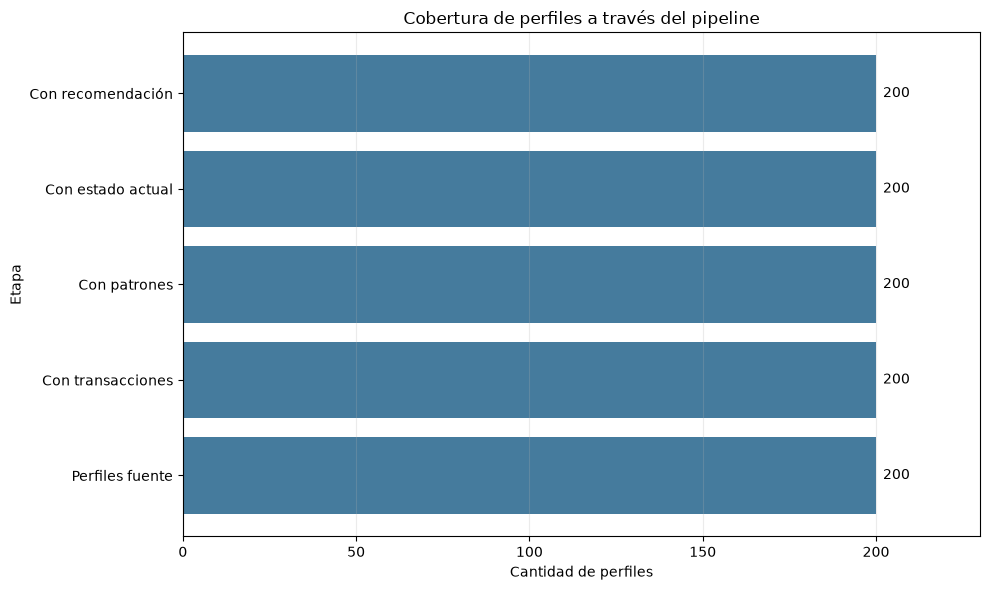

In [18]:
#Graficar cobertura
cobertura_pipeline = pd.Series({
    'Perfiles fuente': perfiles['perfil_id'].nunique(),
    'Con transacciones': transacciones['perfil_id'].nunique(),
    'Con patrones': recurrencias['perfil_id'].nunique(),
    'Con estado actual': estados['perfil_id'].nunique(),
    'Con recomendación': recomendaciones['perfil_id'].nunique(),
}).sort_values()

figura, eje = plt.subplots(figsize=(10, 6))
eje.barh(cobertura_pipeline.index, cobertura_pipeline.values, color='#457B9D')
eje.set_title('Cobertura de perfiles a través del pipeline')
eje.set_xlabel('Cantidad de perfiles')
eje.set_ylabel('Etapa')
eje.set_xlim(0, max(cobertura_pipeline.values) * 1.15)
eje.grid(axis='x', alpha=0.25)

for posicion, valor in enumerate(cobertura_pipeline.values):
    eje.text(valor + 2, posicion, str(int(valor)), va='center')

figura.tight_layout()
figura.savefig(ruta_graficas / '06_cobertura_pipeline.png', dpi=180, bbox_inches='tight')
plt.show()

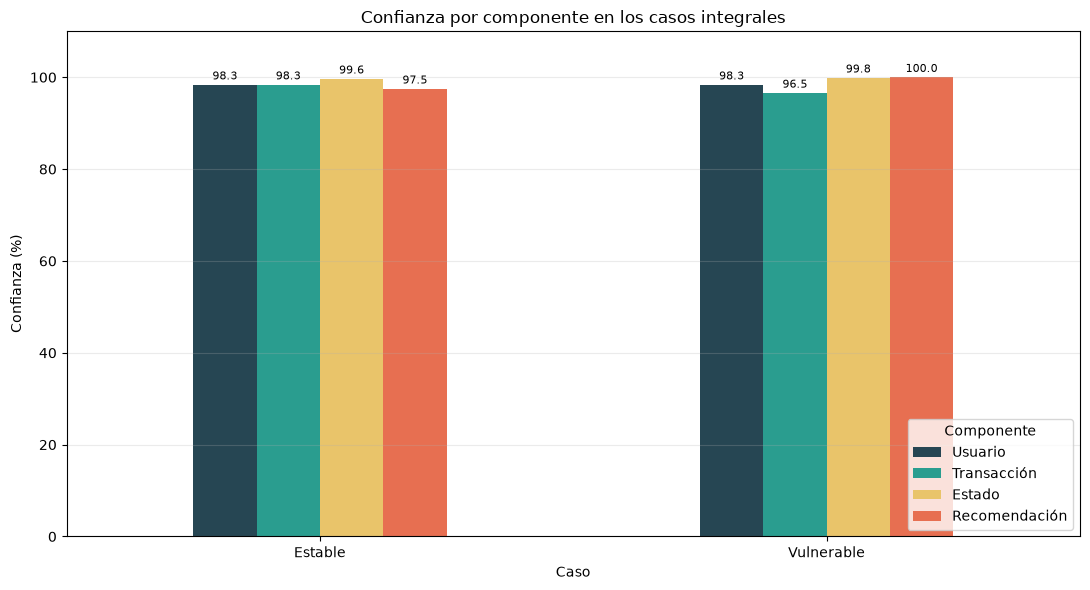

In [19]:
#Graficar confianza
confianzas_casos = pd.DataFrame([
    {
        'caso': 'Estable',
        'Usuario': caso_estable_exportacion['confianza_usuario_pct'],
        'Transacción': caso_estable_exportacion['confianza_transaccion_pct'],
        'Estado': caso_estable_exportacion['confianza_estado_pct'],
        'Recomendación': caso_estable_exportacion['confianza_recomendacion_pct'],
    },
    {
        'caso': 'Vulnerable',
        'Usuario': caso_vulnerable_exportacion['confianza_usuario_pct'],
        'Transacción': caso_vulnerable_exportacion['confianza_transaccion_pct'],
        'Estado': caso_vulnerable_exportacion['confianza_estado_pct'],
        'Recomendación': caso_vulnerable_exportacion['confianza_recomendacion_pct'],
    },
]).set_index('caso')

figura, eje = plt.subplots(figsize=(11, 6))
confianzas_casos.plot(kind='bar', ax=eje, color=['#264653', '#2A9D8F', '#E9C46A', '#E76F51'])
eje.set_title('Confianza por componente en los casos integrales')
eje.set_xlabel('Caso')
eje.set_ylabel('Confianza (%)')
eje.set_ylim(0, 110)
eje.tick_params(axis='x', rotation=0)
eje.grid(axis='y', alpha=0.25)
eje.legend(title='Componente', loc='lower right')

for contenedor in eje.containers:
    eje.bar_label(contenedor, fmt='%.1f', padding=2, fontsize=8)

figura.tight_layout()
figura.savefig(ruta_graficas / '06_confianza_casos_integrales.png', dpi=180, bbox_inches='tight')
plt.show()

## 10. Métricas, limitaciones y exportación

In [20]:
#Consolidar métricas
metricas_componentes = pd.concat([
    metricas_estados.assign(componente='04_estados'),
    metricas_recomendaciones.assign(componente='05_recomendaciones'),
], ignore_index=True)

limitaciones = pd.DataFrame([
    {'limitacion': 'Datos sintéticos', 'impacto': 'Las métricas no demuestran desempeño sobre población real colombiana'},
    {'limitacion': 'Catálogo profesional cerrado', 'impacto': 'Actividades no representadas deben quedar fuera del MVP'},
    {'limitacion': 'Taxonomía transaccional cerrada', 'impacto': 'Descripciones ambiguas pueden requerir confirmación'},
    {'limitacion': 'Una recomendación por estado', 'impacto': 'El motor selecciona un catálogo restringido y no crea alternativas libres'},
    {'limitacion': 'Integración por artefactos', 'impacto': 'Los resultados temporales deben regenerarse si cambian los datos fuente'},
])

display(metricas_componentes.round(4))
display(limitaciones)

,modelo,accuracy,balanced_accuracy,f1_macro,log_loss,particion,componente
0,bosque_aleatorio,0.9889,0.9821,0.9810,0.1603,validation,04_estados
1,regresion_logistica,0.9333,0.9267,0.9158,0.2776,validation,04_estados
2,bosque_aleatorio,0.9667,0.9524,0.9491,0.1552,test,04_estados
3,bosque_aleatorio,1.0000,1.0000,1.0000,0.0063,validation,05_recomendaciones
4,regresion_logistica,1.0000,1.0000,1.0000,0.0121,validation,05_recomendaciones
5,bosque_aleatorio,0.9778,0.9702,0.9675,0.0743,test,05_recomendaciones


,limitacion,impacto
0,Datos sintéticos,Las métricas no demuestran desempeño sobre pob...
1,Catálogo profesional cerrado,Actividades no representadas deben quedar fuer...
2,Taxonomía transaccional cerrada,Descripciones ambiguas pueden requerir confirm...
3,Una recomendación por estado,El motor selecciona un catálogo restringido y ...
4,Integración por artefactos,Los resultados temporales deben regenerarse si...


In [21]:
#Exportar cierre
ruta_trazabilidad = ruta_resultados / '06_trazabilidad_perfiles.csv'
ruta_controles = ruta_resultados / '06_controles_pipeline.csv'
ruta_casos = ruta_resultados / '06_casos_validacion.csv'
ruta_metricas = ruta_resultados / '06_metricas_componentes.csv'

controles_finales = pd.concat([
    controles_integracion.assign(tipo='integracion'),
    controles_eticos.assign(tipo='etica'),
], ignore_index=True)

trazabilidad.to_csv(ruta_trazabilidad, index=False)
controles_finales.to_csv(ruta_controles, index=False)
casos_integrales.to_csv(ruta_casos, index=False)
metricas_componentes.to_csv(ruta_metricas, index=False)

archivos_generados = pd.DataFrame([
    {'artefacto': 'trazabilidad de perfiles', 'ruta': str(ruta_trazabilidad), 'filas': len(trazabilidad)},
    {'artefacto': 'controles del pipeline', 'ruta': str(ruta_controles), 'filas': len(controles_finales)},
    {'artefacto': 'casos de validación', 'ruta': str(ruta_casos), 'filas': len(casos_integrales)},
    {'artefacto': 'métricas consolidadas', 'ruta': str(ruta_metricas), 'filas': len(metricas_componentes)},
])

display(archivos_generados)
assert trazabilidad['recorrido_completo'].all(), 'Algún perfil no completó el recorrido por los productos disponibles'

,artefacto,ruta,filas
0,trazabilidad de perfiles,../Resultados/06_trazabilidad_perfiles.csv,200
1,controles del pipeline,../Resultados/06_controles_pipeline.csv,13
2,casos de validación,../Resultados/06_casos_validacion.csv,3
3,métricas consolidadas,../Resultados/06_metricas_componentes.csv,6


## 11. Pruebas

In [22]:
#Probar caso estable
caso_estable = recorrer_perfil('PERF_0050')
display(pd.Series(caso_estable, name='caso_estable').to_frame())

assert caso_estable['estado_alcance_usuario'] == 'dentro_del_mvp'
assert caso_estable['estado_trayectoria'] == 'acumulacion_estable'
assert caso_estable['recomendacion_id'] == 'REC_MANTENER_ACUMULACION'
assert caso_estable['resultado_integracion'] == 'recorrido_completo'

,caso_estable
perfil_id,PERF_0050
descripcion_usuario,Trabajo como barbero. Quiero hacer viaje.
actividad_esperada,peluqueria_y_barberia
actividad_modelo,peluqueria_y_barberia
confianza_usuario_pct,98.34
estado_alcance_usuario,dentro_del_mvp
transaccion_id,TX_0050_0025
descripcion_transaccion,LABORATORIO CLINICO
categoria_esperada,Salud
categoria_modelo,Salud


In [ ]:
#Probar caso vulnerable
caso_vulnerable = recorrer_perfil('PERF_0160')

display(pd.Series(caso_vulnerable, name='caso_vulnerable').to_frame())

assert caso_vulnerable['estado_alcance_usuario'] == 'dentro_del_mvp'
assert caso_vulnerable['estado_trayectoria'] == 'fragilidad_sostenida'
assert caso_vulnerable['recomendacion_id'] == 'REC_PRIORIZAR_COBERTURA'
assert 'proteccion_esencial_por_fragilidad' in caso_vulnerable['guardas_aplicadas']

In [ ]:
#Probar caso fuera del MVP
caso_fuera_mvp = evaluar_fuera_mvp('Trabajo como mecánico automotriz y reparo vehículos')

display(pd.Series(caso_fuera_mvp, name='caso_fuera_mvp').to_frame())

assert caso_fuera_mvp['estado_alcance_usuario'] == 'no_disponible'
assert caso_fuera_mvp['etapa_detencion'] == '01_conocimiento_usuario'
assert caso_fuera_mvp['clasificacion_transaccion'] == 'no_evaluada'
assert caso_fuera_mvp['recomendacion_id'] == 'no_disponible'
assert caso_fuera_mvp['resultado_integracion'] == 'abstencion_correcta'